# LiDAR SLAM Detector Filtering Analysis (KITTI + Genz-ICP)

This notebook analyzes how removing detected objects from LiDAR point clouds affects SLAM accuracy.

It focuses on:
- APE (global trajectory error)
- RPE (local frame-to-frame error)
- FOV effects (front FOV vs full scan)
- Detector/class configuration effects
- Whether removing only moving objects helps odometry
- Distance threshold effects (`dist max` = `NO` vs `20`)
- Sequence-specific behavior

In [50]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid', context='notebook')

In [51]:
CSV_PATH = 'tfg_results_complete_ape&rpe_rad.csv'

def load_and_clean(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep=';')
    df = df.dropna(axis=1, how='all')
    df = df.dropna(subset=['sequence'])

    cat_cols = ['FOV', 'Detector', 'classes', 'dist max']
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()

    metric_cols = [col for col in df.columns if col not in cat_cols + ['sequence', 'test', 'experiment']]
    for col in metric_cols:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '.', regex=False), errors='coerce')

    for col in ['sequence', 'test', 'experiment']:
        if col in df.columns:
            df[col] = df[col].astype('Int64')

    return df

df = load_and_clean(CSV_PATH)
print(f'Rows: {len(df)}')
print(f'Columns: {len(df.columns)}')
df.head()

Rows: 220
Columns: 23


,sequence,test,experiment,FOV,Detector,classes,dist max,ape_t_mean,ape_t_median,ape_t_std,ape_t_max,rpe_t_mean,rpe_t_median,rpe_t_std,rpe_t_max,ape_r_mean,ape_r_median,ape_r_std,ape_r_max,rpe_r_mean,rpe_r_median,rpe_r_std,rpe_r_max
0,0,0,1,NO,NO,NO,NO,11.078589,10.259416,5.103415,24.485214,0.025276,0.020421,0.021713,0.280997,0.049276,0.047001,0.012774,0.130020,0.001378,0.000936,0.001863,0.038780
1,0,0,2,YES,NO,NO,NO,14.508833,12.704135,9.154027,46.854468,0.024434,0.020448,0.020201,0.299897,0.032303,0.024286,0.024602,0.125953,0.001415,0.001038,0.001789,0.039357
2,0,1,1,YES,3D-MOOD,KITTI,NO,13.645740,10.238855,9.810478,48.875648,0.024449,0.020473,0.020295,0.292080,0.040227,0.030705,0.025883,0.129951,0.001415,0.001043,0.001782,0.039138
3,0,1,2,YES,PV-RCNN,KITTI,20,14.722212,12.977666,9.778717,48.211377,0.024603,0.020631,0.020408,0.316323,0.032380,0.023699,0.025468,0.125512,0.001413,0.001046,0.001771,0.038911
4,0,1,1,YES,SEM KITTI,SK_KITTI,NO,14.800067,12.326739,11.168190,54.012488,0.024683,0.020708,0.020235,0.304877,0.040284,0.033350,0.029017,0.124258,0.001387,0.001031,0.001775,0.038265


In [52]:
print('Unique configuration values:')
for col in ['sequence', 'experiment', 'FOV', 'Detector', 'classes', 'dist max']:
    if col in df.columns:
        values = sorted(df[col].dropna().unique().tolist())
        print(f'- {col}: {values}')

print('\\nNumber of runs per (FOV, Detector, classes):')
display(df.groupby(['FOV', 'Detector', 'classes']).size().rename('runs').reset_index().sort_values(['FOV', 'runs'], ascending=[True, False]))

Unique configuration values:
- sequence: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
- experiment: [1, 2]
- FOV: ['NO', 'YES']
- Detector: ['3D-MOOD', 'NO', 'PV-RCNN', 'SEM KITTI']
- classes: ['KITTI', 'MOOD_COMPLETE', 'NO', 'SK_COMPLETE', 'SK_KITTI', 'SK_MOVING']
- dist max: ['20', 'NO']
\nNumber of runs per (FOV, Detector, classes):


,FOV,Detector,classes,runs
1,NO,PV-RCNN,KITTI,22
2,NO,SEM KITTI,SK_KITTI,22
3,NO,SEM KITTI,SK_MOVING,22
0,NO,NO,NO,11
4,YES,3D-MOOD,KITTI,22
5,YES,3D-MOOD,MOOD_COMPLETE,22
7,YES,PV-RCNN,KITTI,22
8,YES,SEM KITTI,SK_COMPLETE,22
9,YES,SEM KITTI,SK_KITTI,22
10,YES,SEM KITTI,SK_MOVING,22


## 1) Global Summary by Configuration

We summarize mean APE/RPE metrics by `(FOV, Detector, classes)` to compare broad trends.

In [53]:
main_metrics = ['ape_t_mean', 'rpe_t_mean', 'ape_r_mean', 'rpe_r_mean']
summary = (
    df.groupby(['FOV', 'Detector', 'classes'])[main_metrics]
      .mean()
      .reset_index()
      .sort_values(['FOV', 'ape_t_mean', 'rpe_t_mean'])
)
display(summary)

,FOV,Detector,classes,ape_t_mean,rpe_t_mean,ape_r_mean,rpe_r_mean
0,NO,NO,NO,17.852906,0.024804,0.047194,0.000947
1,NO,PV-RCNN,KITTI,17.877090,0.024871,0.047069,0.000946
3,NO,SEM KITTI,SK_MOVING,17.882594,0.024835,0.047234,0.000947
2,NO,SEM KITTI,SK_KITTI,17.895535,0.024866,0.047362,0.000944
6,YES,NO,NO,11.008873,0.026737,0.031150,0.001014
5,YES,3D-MOOD,MOOD_COMPLETE,11.018494,0.026702,0.032453,0.001019
4,YES,3D-MOOD,KITTI,11.081260,0.026763,0.031690,0.001018
7,YES,PV-RCNN,KITTI,11.085133,0.026893,0.031204,0.001013
9,YES,SEM KITTI,SK_KITTI,11.133491,0.028148,0.031057,0.001010
10,YES,SEM KITTI,SK_MOVING,11.194894,0.027085,0.031651,0.001007


### 1) Interpretation

Initially, it looks that applying the FOV filter improves (greatly) the APE.

## 1.1) Effect of FOV filter by configuration

The following cells show the Mean APE and RPE error, grouped by Detector and divided by the FOV setting.

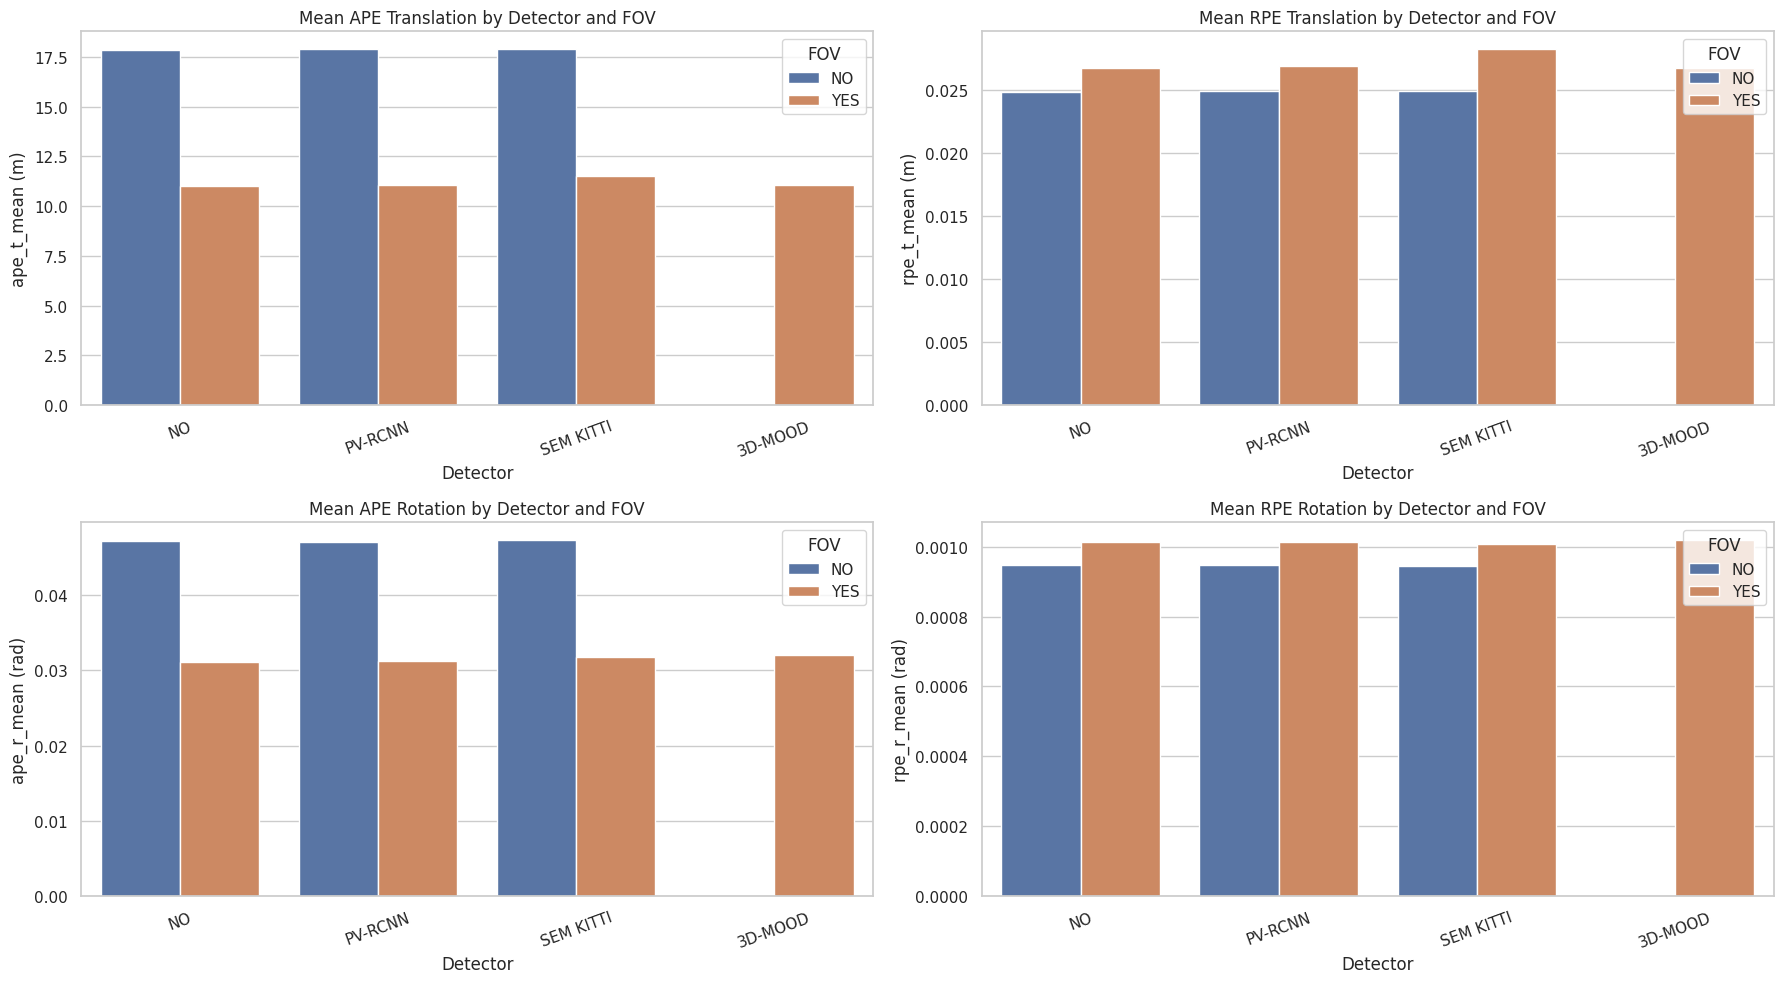

In [54]:
# Inicializar la figura de 2x2
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

# 1. Primer gráfico (Fila 1, Columna 1)
sns.barplot(data=summary, x='Detector', y='ape_t_mean', hue='FOV', ax=axes[0], errorbar=None)
axes[0].set_title('Mean APE Translation by Detector and FOV')
axes[0].set_ylabel('ape_t_mean (m)')
axes[0].tick_params(axis='x', rotation=20)

# 2. Segundo gráfico (Fila 1, Columna 2)
sns.barplot(data=summary, x='Detector', y='rpe_t_mean', hue='FOV', ax=axes[1], errorbar=None)
axes[1].set_title('Mean RPE Translation by Detector and FOV')
axes[1].set_ylabel('rpe_t_mean (m)')
axes[1].tick_params(axis='x', rotation=20)

# 3. Tercer gráfico (Fila 2, Columna 1)
sns.barplot(data=summary, x='Detector', y='ape_r_mean', hue='FOV', ax=axes[2], errorbar=None)
axes[2].set_title('Mean APE Rotation by Detector and FOV')
axes[2].set_ylabel('ape_r_mean (rad)')
axes[2].tick_params(axis='x', rotation=20)

# 4. Cuarto gráfico (Fila 2, Columna 2)
sns.barplot(data=summary, x='Detector', y='rpe_r_mean', hue='FOV', ax=axes[3], errorbar=None)
axes[3].set_title('Mean RPE Rotation by Detector and FOV')
axes[3].set_ylabel('rpe_r_mean (rad)')
axes[3].tick_params(axis='x', rotation=20)

# Ajustar elementos y mostrar
plt.tight_layout()
plt.show()


### 1.1) Interpretation

In every configuration, removing all points except those in the camera's FOV have the same effect: The APE decreases greatly, but the RPE increases slightly.
Possible explanation:
1. Full cloud gives stronger frame-to-frame constraints, so RPE improves.
2. APE should improve too, but full clouds may also introduce a small systematic bias each step (especially from side points), so drift accumulates and APE gets much worse.


Example to help understand this part:
- Frame-to-frame error can be "modeled" od "decomposed" as random part + bias:
  - Random noise increases RPE but often cancels over time (does not affect APE globally too much)
  - Small bias may barely affect RPE but accumulates strongly in APE
- Points from lateral objects will be visible for a shorter time than points in the front/back.
- So FOV filter can increase random error slightly while reducing bias a lot.

It is important to notice that applying a deskew to the point cloud to compensate the ego-vehicle movement did not change the results.


Additional checks to confirm the hypothesis (future work):
1. Plot RPE distributions (not just mean) using evo_res: median, tails, outliers.
2. Recompute with different RPE delta lengths (1, 5, 10 frames) to see bias growth.
3. Evaluate sector ablations:
    - front only
    - front + rear (remove only sides)
    - sides only
This could help reveal which sector conttributes more to the drift.


## 1.2) Further analysis: Separating Detector and classes

Same plot as before, but separating by Detector and classes, to see if there are big differences between prompts / SK settings.

## 2) Relative Change vs Baseline

We compare each configuration against baseline `(Detector=NO, classes=NO)` within each FOV.

In [55]:
def add_relative_to_baseline(s: pd.DataFrame, metric: str) -> pd.DataFrame:
    s = s.copy()
    base = (
        s[(s['Detector'] == 'NO') & (s['classes'] == 'NO')][['FOV', metric]]
        .rename(columns={metric: f'{metric}_baseline'})
    )
    s = s.merge(base, on='FOV', how='left')
    s[f'{metric}_diff'] = s[metric] - s[f'{metric}_baseline']
    s[f'{metric}_diff_%'] = 100.0 * s[f'{metric}_diff'] / s[f'{metric}_baseline']
    return s

summary_rel = add_relative_to_baseline(summary, 'ape_t_mean')
summary_rel = add_relative_to_baseline(summary_rel, 'rpe_t_mean')
display(summary_rel[['FOV', 'Detector', 'classes', 'ape_t_mean', 'ape_t_mean_diff', 'ape_t_mean_diff_%', 'rpe_t_mean', 'rpe_t_mean_diff', 'rpe_t_mean_diff_%']].sort_values(['FOV', 'rpe_t_mean_diff_%']))

# 1. Asegurar que calculamos las métricas relativas sobre TODO el conjunto disponible
summary_completo = add_relative_to_baseline(summary, 'ape_t_mean')
summary_completo = add_relative_to_baseline(summary_completo, 'rpe_t_mean')

def extraer_tabla_simetrica(df_fuente, fov_valor):
    # Filtrar por el FOV deseado
    sub_df = df_fuente[df_fuente['FOV'] == fov_valor].copy()
    
    # Seleccionar, ordenar de mejor a peor error absoluto y renombrar
    columnas = ['Detector', 'classes', 'ape_t_mean', 'ape_t_mean_diff_%', 'rpe_t_mean', 'rpe_t_mean_diff_%']
    sub_df = sub_df[columnas].sort_values('ape_t_mean_diff_%')
    sub_df.columns = ['Detector', 'Config. Clases', 'APE Medio (m)', 'Δ APE (%)', 'RPE Medio (m)', 'Δ RPE (%)']
    
    # Formatear decimales
    sub_df = sub_df.round({'APE Medio (m)': 3, 'RPE Medio (m)': 4})
    
    def format_pct(val):
        if pd.isna(val): return "N/A"  # Por si esa prueba no existe en el DataFrame
        if val > 0: return f"+{val:.2f}%"
        if val < 0: return f"{val:.2f}%"
        return "0.00% (Base)"
        
    sub_df['Δ APE (%)'] = sub_df['Δ APE (%)'].apply(format_pct)
    sub_df['Δ RPE (%)'] = sub_df['Δ RPE (%)'].apply(format_pct)
    
    return sub_df

# Generar ambas de forma explícita
tabla_completa_no = extraer_tabla_simetrica(summary_completo, 'NO')
tabla_completa_yes = extraer_tabla_simetrica(summary_completo, 'YES')

print(f"Filas encontradas para FOV=NO: {len(tabla_completa_no)}")
print(f"Filas encontradas para FOV=YES: {len(tabla_completa_yes)}\n")

print("--- TODAS LAS CONFIGURACIONES DISPONIBLES PARA FOV = NO ---")
display(tabla_completa_no)

print("\n--- TODAS LAS CONFIGURACIONES DISPONIBLES PARA FOV = YES ---")
display(tabla_completa_yes)

# Reemplaza 'tabla_completa_yes' por la tabla que quieras exportar
tabla_completa_yes.to_csv('tabla_completa_yes.csv', index=False)
# print(tabla_completa_no.to_latex(index=False, caption="Resultados para FOV = YES", label="tab:fov_yes"))




,FOV,Detector,classes,ape_t_mean,ape_t_mean_diff,ape_t_mean_diff_%,rpe_t_mean,rpe_t_mean_diff,rpe_t_mean_diff_%
0,NO,NO,NO,17.852906,0.000000,0.000000,0.024804,0.000000,0.000000
2,NO,SEM KITTI,SK_MOVING,17.882594,0.029687,0.166289,0.024835,0.000032,0.127284
3,NO,SEM KITTI,SK_KITTI,17.895535,0.042629,0.238779,0.024866,0.000062,0.251399
1,NO,PV-RCNN,KITTI,17.877090,0.024183,0.135460,0.024871,0.000067,0.270473
5,YES,3D-MOOD,MOOD_COMPLETE,11.018494,0.009621,0.087394,0.026702,-0.000035,-0.130198
4,YES,NO,NO,11.008873,0.000000,0.000000,0.026737,0.000000,0.000000
6,YES,3D-MOOD,KITTI,11.081260,0.072387,0.657531,0.026763,0.000026,0.096743
7,YES,PV-RCNN,KITTI,11.085133,0.076261,0.692719,0.026893,0.000156,0.584275
9,YES,SEM KITTI,SK_MOVING,11.194894,0.186021,1.689738,0.027085,0.000348,1.299982
8,YES,SEM KITTI,SK_KITTI,11.133491,0.124618,1.131981,0.028148,0.001411,5.277432


Filas encontradas para FOV=NO: 4
Filas encontradas para FOV=YES: 7

--- TODAS LAS CONFIGURACIONES DISPONIBLES PARA FOV = NO ---


,Detector,Config. Clases,APE Medio (m),Δ APE (%),RPE Medio (m),Δ RPE (%)
0,NO,NO,17.853,0.00% (Base),0.0248,0.00% (Base)
1,PV-RCNN,KITTI,17.877,+0.14%,0.0249,+0.27%
2,SEM KITTI,SK_MOVING,17.883,+0.17%,0.0248,+0.13%
3,SEM KITTI,SK_KITTI,17.896,+0.24%,0.0249,+0.25%



--- TODAS LAS CONFIGURACIONES DISPONIBLES PARA FOV = YES ---


,Detector,Config. Clases,APE Medio (m),Δ APE (%),RPE Medio (m),Δ RPE (%)
4,NO,NO,11.009,0.00% (Base),0.0267,0.00% (Base)
5,3D-MOOD,MOOD_COMPLETE,11.018,+0.09%,0.0267,-0.13%
6,3D-MOOD,KITTI,11.081,+0.66%,0.0268,+0.10%
7,PV-RCNN,KITTI,11.085,+0.69%,0.0269,+0.58%
8,SEM KITTI,SK_KITTI,11.133,+1.13%,0.0281,+5.28%
9,SEM KITTI,SK_MOVING,11.195,+1.69%,0.0271,+1.30%
10,SEM KITTI,SK_COMPLETE,12.285,+11.60%,0.0294,+9.84%


## 3) Distance Threshold Effect (`dist max` = `NO` vs `20`)

Paired analysis for configurations where both distance settings exist.

### 2) Interpretation

Nothing beats the baseline, which rejects one of the initial hypothesis (removing points from some type of objects could improve SLAM).

There is only one configuration which gets a better error (3DMOOD with full prompt), but only in RPE and only by 0.03mm. The original ground truth is not accurate enough to consider this as an improvement, so we can consider they have an equivalent error.

### Why this is happening
By removing points from objects, we are reducing the amount of information available to the SLAM system. Even though we are only removing points from objects which are prone to move and to generate spurious correspondences (vehicles, pedestrians, or vegetation), most of those objects will probably be static (e.g. parked cars).

Thus, removing those points does affect negatively the perfoemance of the SLAM algorithm. On the one hand, we are removing useful information from static objects. On the other hand, if the SLAM algorithm is a robust method, it may have mechanisms to filter out outliers during the ICP cloud registration. This should make it very dependent on the type of environment (e.g. highway vs urban).

In Section 4 we will analyse the effect of removing only those objects that are actually moving (only in SemanticKITTI). In Section 5 we will analyse the error by KITTI sequence.



In [56]:
dist_summary = (
    df.groupby(['FOV', 'Detector', 'classes', 'dist max'])[['ape_t_mean', 'rpe_t_mean']]
      .mean()
      .reset_index()
)
display(dist_summary.sort_values(['FOV', 'Detector', 'classes', 'dist max']))

ape_pivot = dist_summary.pivot_table(index=['FOV', 'Detector', 'classes'], columns='dist max', values='ape_t_mean')
rpe_pivot = dist_summary.pivot_table(index=['FOV', 'Detector', 'classes'], columns='dist max', values='rpe_t_mean')
paired = pd.DataFrame({
    'ape_20_minus_NO': ape_pivot.get('20') - ape_pivot.get('NO'),
    'rpe_20_minus_NO': rpe_pivot.get('20') - rpe_pivot.get('NO'),
}).dropna()


# 1. Asegurar la estructura plana del DataFrame paridado de distancias
paired_plano = paired.reset_index()

def generar_tabla_distancia_corregida(df_paired, fov_valor):
    # Filtrar por la condición de Campo de Visión (FoV)
    sub_df = df_paired[df_paired['FOV'] == fov_valor].copy()
    
    # Seleccionar las columnas originales y ordenar (los valores más negativos van arriba)
    sub_df = sub_df[['Detector', 'classes', 'ape_20_minus_NO', 'rpe_20_minus_NO']].sort_values('ape_20_minus_NO')
    
    # CORRECCIÓN DEFINITIVA DE CABECERAS: Ambas métricas miden traslación y van en metros (m)
    sub_df.columns = [
        'Detector', 
        'Config. Clases', 
        'Δ APE Absoluto (m)', 
        'Δ RPE Traslación (m)'
    ]
    
    # Redondeo de alta resolución para evitar empates visuales en el editor
    sub_df = sub_df.round({
        'Δ APE Absoluto (m)': 3, 
        'Δ RPE Traslación (m)': 6
    })
    
    # Formatear como texto para forzar que los valores positivos muestren el signo '+'
    def formatear_signo_ape(val):
        if pd.isna(val): return "N/A"
        return f"+{val:.3f}" if val > 0 else f"{val:.3f}"
        
    def formatear_signo_rpe(val):
        if pd.isna(val): return "N/A"
        return f"+{val:.6f}" if val > 0 else f"{val:.6f}"
        
    sub_df['Δ APE Absoluto (m)'] = sub_df['Δ APE Absoluto (m)'].apply(formatear_signo_ape)
    sub_df['Δ RPE Traslación (m)'] = sub_df['Δ RPE Traslación (m)'].apply(formatear_signo_rpe)
    
    return sub_df

# 2. Generar las vistas limpias para la pantalla del editor
tabla_dist_no = generar_tabla_distancia_corregida(paired_plano, 'NO')
tabla_dist_yes = generar_tabla_distancia_corregida(paired_plano, 'YES')

# 3. Imprimir los resultados en el editor
print("=========================================================================")
print("📊 COMPATIVADA PARIDADA DE DISTANCIA (20m - NO) | ESCENARIO: FoV = NO")
print("=========================================================================")
display(tabla_dist_no)

print("\n=========================================================================")
print("📊 COMPARATIVA PARIDADA DE DISTANCIA (20m - NO) | ESCENARIO: FoV = YES")
print("=========================================================================")
display(tabla_dist_yes)



,FOV,Detector,classes,dist max,ape_t_mean,rpe_t_mean
0,NO,NO,NO,NO,17.852906,0.024804
1,NO,PV-RCNN,KITTI,20,17.790635,0.024912
2,NO,PV-RCNN,KITTI,NO,17.963545,0.024830
3,NO,SEM KITTI,SK_KITTI,20,17.870670,0.024806
4,NO,SEM KITTI,SK_KITTI,NO,17.920400,0.024926
5,NO,SEM KITTI,SK_MOVING,20,17.860643,0.024762
6,NO,SEM KITTI,SK_MOVING,NO,17.904545,0.024909
7,YES,3D-MOOD,KITTI,20,11.034569,0.027004
8,YES,3D-MOOD,KITTI,NO,11.127950,0.026522
9,YES,3D-MOOD,MOOD_COMPLETE,20,10.912682,0.026777


📊 COMPATIVADA PARIDADA DE DISTANCIA (20m - NO) | ESCENARIO: FoV = NO


,Detector,Config. Clases,Δ APE Absoluto (m),Δ RPE Traslación (m)
0,PV-RCNN,KITTI,-0.173,+0.000082
1,SEM KITTI,SK_KITTI,-0.050,-0.000119
2,SEM KITTI,SK_MOVING,-0.044,-0.000147



📊 COMPARATIVA PARIDADA DE DISTANCIA (20m - NO) | ESCENARIO: FoV = YES


,Detector,Config. Clases,Δ APE Absoluto (m),Δ RPE Traslación (m)
6,SEM KITTI,SK_COMPLETE,-0.616,-0.000455
4,3D-MOOD,MOOD_COMPLETE,-0.212,+0.000150
3,3D-MOOD,KITTI,-0.093,+0.000482
8,SEM KITTI,SK_MOVING,+0.046,-0.001202
5,PV-RCNN,KITTI,+0.198,+0.001088
7,SEM KITTI,SK_KITTI,+0.338,+0.002783


### 3) Interpretation

Negative values mean dist max=20 is better (lower error).

This is consistent with the results obtained before: Removing more points degrades the performance.
By limiting the maximum distance where detections are included, we are in fact filtering less objects, thus feeding more points to the SLAM and improving the performance.

In [57]:
sem_classes = ['SK_MOVING', 'SK_KITTI', 'SK_COMPLETE']
moving_compare = summary_rel[
    ((summary_rel['Detector'] == 'SEM KITTI') & (summary_rel['classes'].isin(sem_classes)))
    | ((summary_rel['Detector'] == 'NO') & (summary_rel['classes'] == 'NO'))
] .copy()
display(moving_compare[['FOV', 'Detector', 'classes', 'ape_t_mean', 'ape_t_mean_diff_%', 'rpe_t_mean', 'rpe_t_mean_diff_%']].sort_values(['FOV', 'classes']))

,FOV,Detector,classes,ape_t_mean,ape_t_mean_diff_%,rpe_t_mean,rpe_t_mean_diff_%
0,NO,NO,NO,17.852906,0.000000,0.024804,0.000000
3,NO,SEM KITTI,SK_KITTI,17.895535,0.238779,0.024866,0.251399
2,NO,SEM KITTI,SK_MOVING,17.882594,0.166289,0.024835,0.127284
4,YES,NO,NO,11.008873,0.000000,0.026737,0.000000
10,YES,SEM KITTI,SK_COMPLETE,12.285395,11.595397,0.029368,9.839396
8,YES,SEM KITTI,SK_KITTI,11.133491,1.131981,0.028148,5.277432
9,YES,SEM KITTI,SK_MOVING,11.194894,1.689738,0.027085,1.299982


## 4) Removing Only Moving Objects

This section compares baseline, `SK_MOVING`, `SK_KITTI`, and `SK_COMPLETE`.
The idea is to determine if removing only dynamic (moving) objects makes a difference.

,FOV,Detector,classes,dist max,ape_t_mean,rpe_t_mean,ape_r_mean,rpe_r_mean
0,NO,NO,NO,NO,17.852906,0.024804,0.047194,0.000947
1,NO,SEM KITTI,SK_KITTI,20,17.870670,0.024806,0.047397,0.000945
2,NO,SEM KITTI,SK_KITTI,NO,17.920400,0.024926,0.047327,0.000943
3,NO,SEM KITTI,SK_MOVING,20,17.860643,0.024762,0.047126,0.000950
4,NO,SEM KITTI,SK_MOVING,NO,17.904545,0.024909,0.047343,0.000944
5,YES,NO,NO,NO,11.008873,0.026737,0.031150,0.001014
6,YES,SEM KITTI,SK_COMPLETE,20,11.977418,0.029141,0.034319,0.001015
7,YES,SEM KITTI,SK_COMPLETE,NO,12.593373,0.029595,0.031238,0.000988
8,YES,SEM KITTI,SK_KITTI,20,11.302502,0.029539,0.030464,0.001014
9,YES,SEM KITTI,SK_KITTI,NO,10.964481,0.026757,0.031649,0.001006


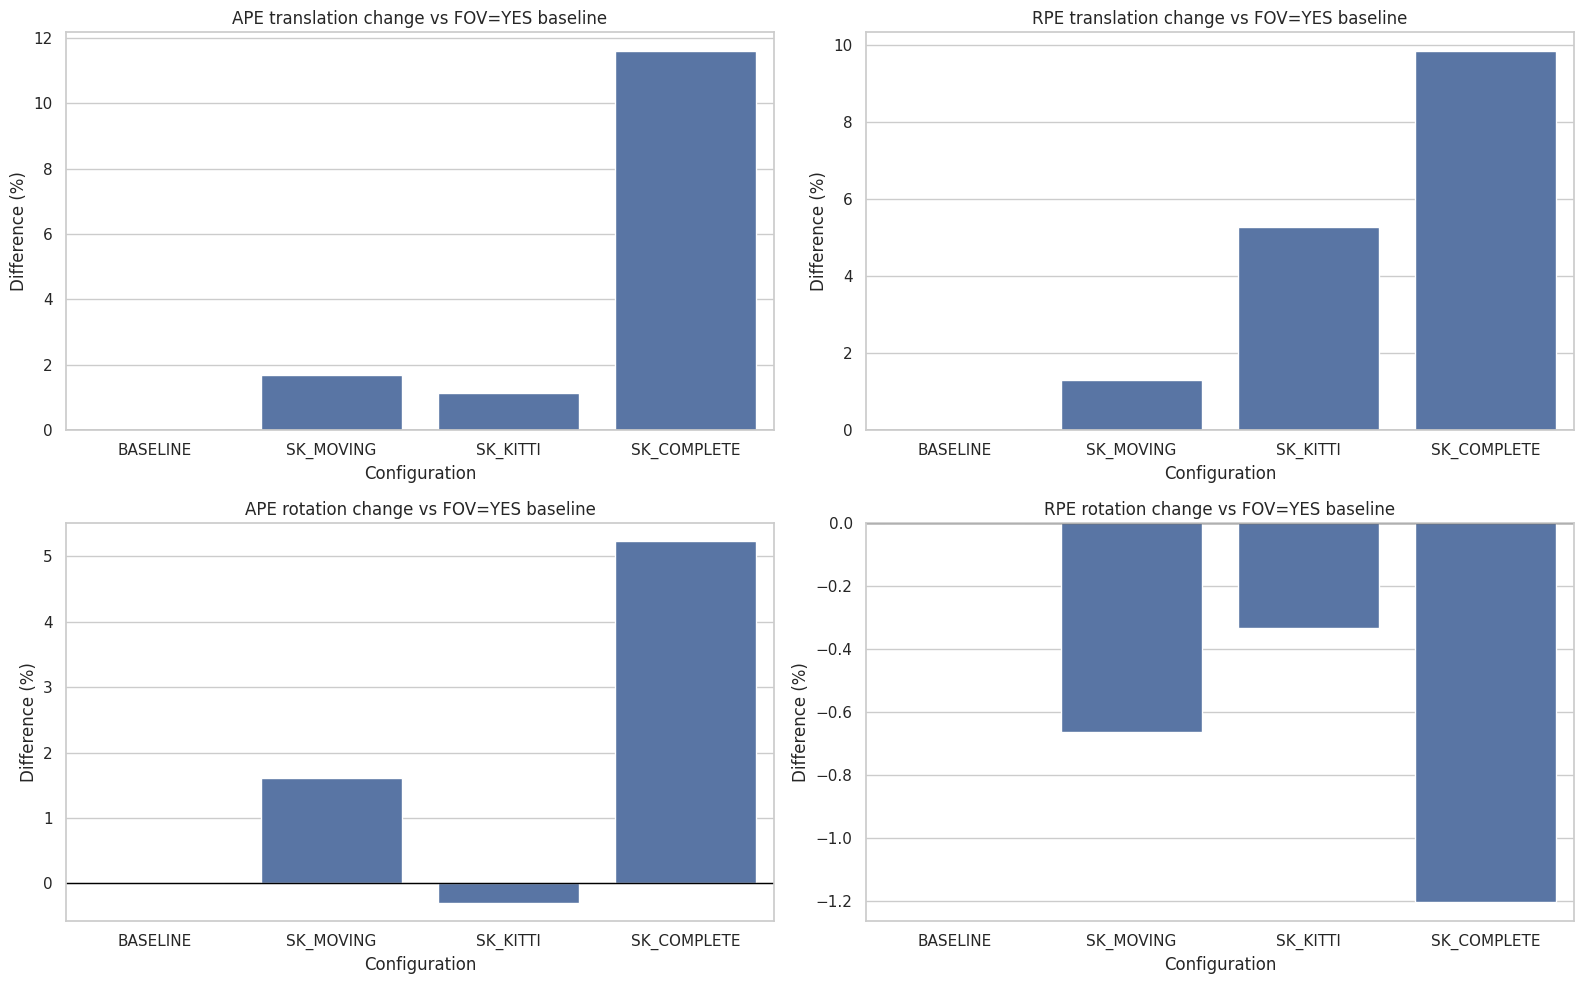

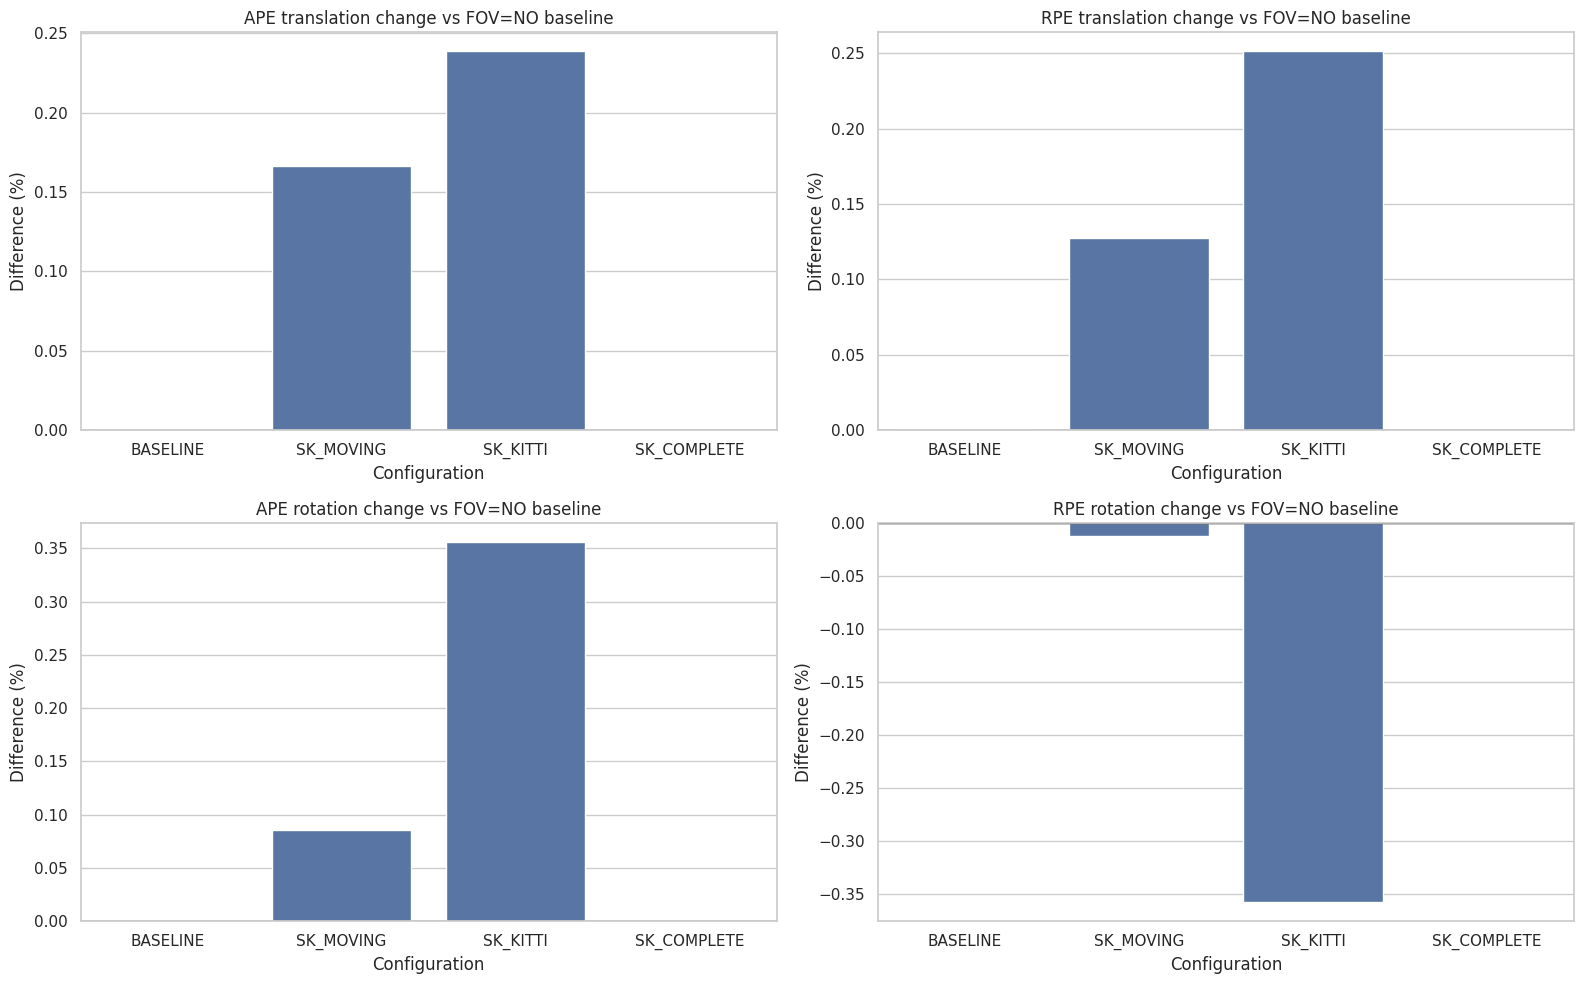

In [58]:
moving_dist_summary = (
    df[
        ((df['Detector'] == 'SEM KITTI') & (df['classes'].isin(sem_classes)))
        | ((df['Detector'] == 'NO') & (df['classes'] == 'NO'))
    ]
    .groupby(['FOV', 'Detector', 'classes', 'dist max'])[['ape_t_mean', 'rpe_t_mean', 'ape_r_mean', 'rpe_r_mean']]
    .mean()
    .reset_index()
)
display(moving_dist_summary.sort_values(['FOV', 'classes', 'dist max']))


plot_data = moving_compare[moving_compare['FOV'] == 'YES'].copy()
plot_data['config'] = np.where(plot_data['Detector'] == 'NO', 'BASELINE', plot_data['classes'])

# Rotation error relative change vs FOV=YES baseline
base_rot_yes = plot_data.loc[plot_data['config'] == 'BASELINE', ['ape_r_mean', 'rpe_r_mean']].iloc[0]
plot_data['ape_r_mean_diff_%'] = 100.0 * (plot_data['ape_r_mean'] - base_rot_yes['ape_r_mean']) / base_rot_yes['ape_r_mean']
plot_data['rpe_r_mean_diff_%'] = 100.0 * (plot_data['rpe_r_mean'] - base_rot_yes['rpe_r_mean']) / base_rot_yes['rpe_r_mean']

order_yes = ['BASELINE', 'SK_MOVING', 'SK_KITTI', 'SK_COMPLETE']
plot_data['config'] = np.where(plot_data['Detector'] == 'NO', 'BASELINE', plot_data['classes'])
order = ['BASELINE', 'SK_MOVING', 'SK_KITTI', 'SK_COMPLETE']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

sns.barplot(data=plot_data, x='config', y='ape_t_mean_diff_%', order=order, ax=axes[0], errorbar=None)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('APE translation change vs FOV=YES baseline')
axes[0].set_ylabel('Difference (%)')
axes[0].set_xlabel('Configuration')
sns.barplot(data=plot_data, x='config', y='rpe_t_mean_diff_%', order=order, ax=axes[1], errorbar=None)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('RPE translation change vs FOV=YES baseline')
axes[1].set_ylabel('Difference (%)')
axes[1].set_xlabel('Configuration')
sns.barplot(data=plot_data, x='config', y='ape_r_mean_diff_%', order=order_yes, ax=axes[2], errorbar=None)
axes[2].axhline(0, color='black', linewidth=1)
axes[2].set_title('APE rotation change vs FOV=YES baseline')
axes[2].set_ylabel('Difference (%)')
axes[2].set_xlabel('Configuration')

sns.barplot(data=plot_data, x='config', y='rpe_r_mean_diff_%', order=order_yes, ax=axes[3], errorbar=None)
axes[3].axhline(0, color='black', linewidth=1)
axes[3].set_title('RPE rotation change vs FOV=YES baseline')
axes[3].set_ylabel('Difference (%)')
axes[3].set_xlabel('Configuration')
plt.tight_layout()
plt.show()

plot_data_no = moving_compare[moving_compare['FOV'] == 'NO'].copy()
plot_data_no['config'] = np.where(plot_data_no['Detector'] == 'NO', 'BASELINE', plot_data_no['classes'])
order_no = ['BASELINE', 'SK_MOVING', 'SK_KITTI', 'SK_COMPLETE']

fig_no, axes_no = plt.subplots(2, 2, figsize=(16, 10))
axes_no = axes_no.flatten()

# Rotation error relative change vs FOV=NO baseline
base_rot_no = plot_data_no.loc[plot_data_no['config'] == 'BASELINE', ['ape_r_mean', 'rpe_r_mean']].iloc[0]
plot_data_no['ape_r_mean_diff_%'] = 100.0 * (plot_data_no['ape_r_mean'] - base_rot_no['ape_r_mean']) / base_rot_no['ape_r_mean']
plot_data_no['rpe_r_mean_diff_%'] = 100.0 * (plot_data_no['rpe_r_mean'] - base_rot_no['rpe_r_mean']) / base_rot_no['rpe_r_mean']

sns.barplot(data=plot_data_no, x='config', y='ape_t_mean_diff_%', order=order_no, ax=axes_no[0], errorbar=None)
axes_no[0].axhline(0, color='black', linewidth=1)
axes_no[0].set_title('APE translation change vs FOV=NO baseline')
axes_no[0].set_ylabel('Difference (%)')
axes_no[0].set_xlabel('Configuration')

sns.barplot(data=plot_data_no, x='config', y='rpe_t_mean_diff_%', order=order_no, ax=axes_no[1], errorbar=None)
axes_no[1].axhline(0, color='black', linewidth=1)
axes_no[1].set_title('RPE translation change vs FOV=NO baseline')
axes_no[1].set_ylabel('Difference (%)')
axes_no[1].set_xlabel('Configuration')

sns.barplot(data=plot_data_no, x='config', y='ape_r_mean_diff_%', order=order_no, ax=axes_no[2], errorbar=None)
axes_no[2].axhline(0, color='black', linewidth=1)
axes_no[2].set_title('APE rotation change vs FOV=NO baseline')
axes_no[2].set_ylabel('Difference (%)')
axes_no[2].set_xlabel('Configuration')

sns.barplot(data=plot_data_no, x='config', y='rpe_r_mean_diff_%', order=order_no, ax=axes_no[3], errorbar=None)
axes_no[3].axhline(0, color='black', linewidth=1)
axes_no[3].set_title('RPE rotation change vs FOV=NO baseline')
axes_no[3].set_ylabel('Difference (%)')
axes_no[3].set_xlabel('Configuration')

plt.tight_layout()
plt.show()


### 4) Interpretation

Even when only removing the points from moving objects, the odometry results still do not beat the baseline with the original point cloud.

Geenerally, there seems to be a correspondence between the error and the number of points removed, following the results obtained in Section 3. The more objects we remove, the worse it gets.

There is some slight improvement in the RPE rotation metric.

Note that there is no data for SK_COMPLETE with FOV=NO.

### Possible explanation
The SLAM method is robust enough to work with dynamic objects.
TODO: This requires more thought.

### 4.1) Removing Only Moving Objects - By sequence

Same analysis, but isolating each sequence to determine if there is any situation (maybe highway) where removing dynamic objects matter.

In [59]:
sem_yes_base = df[df['FOV'] == 'YES'].copy()
sem_yes = sem_yes_base[((sem_yes_base['Detector'] == 'SEM KITTI') & (sem_yes_base['classes'].isin(sem_classes))) | ((sem_yes_base['Detector'] == 'NO') & (sem_yes_base['classes'] == 'NO'))].copy()
sem_yes_seq_ape = sem_yes.pivot_table(index='sequence', columns=['Detector', 'classes'], values='ape_t_mean', aggfunc='mean')
sem_yes_seq_rpe = sem_yes.pivot_table(index='sequence', columns=['Detector', 'classes'], values='rpe_t_mean', aggfunc='mean')
sem_yes_ape_delta = pd.DataFrame({
    'SK_MOVING': sem_yes_seq_ape[('SEM KITTI', 'SK_MOVING')] - sem_yes_seq_ape[('NO', 'NO')],
    'SK_KITTI': sem_yes_seq_ape[('SEM KITTI', 'SK_KITTI')] - sem_yes_seq_ape[('NO', 'NO')],
    'SK_COMPLETE': sem_yes_seq_ape[('SEM KITTI', 'SK_COMPLETE')] - sem_yes_seq_ape[('NO', 'NO')],
})
sem_yes_rpe_delta = pd.DataFrame({
    'SK_MOVING': sem_yes_seq_rpe[('SEM KITTI', 'SK_MOVING')] - sem_yes_seq_rpe[('NO', 'NO')],
    'SK_KITTI': sem_yes_seq_rpe[('SEM KITTI', 'SK_KITTI')] - sem_yes_seq_rpe[('NO', 'NO')],
    'SK_COMPLETE': sem_yes_seq_rpe[('SEM KITTI', 'SK_COMPLETE')] - sem_yes_seq_rpe[('NO', 'NO')],
})

print('APE and RPE deltas for FOV=YES:')
combined_sem_yes_delta = pd.concat(
    {'APE': sem_yes_ape_delta, 'RPE': sem_yes_rpe_delta},
    axis=1
)
display(combined_sem_yes_delta)

sem_no_base = df[df['FOV'] == 'NO'].copy()
sem_no = sem_no_base[((sem_no_base['Detector'] == 'SEM KITTI') & (sem_no_base['classes'].isin(sem_classes))) | ((sem_no_base['Detector'] == 'NO') & (sem_no_base['classes'] == 'NO'))].copy()
sem_no_seq_ape = sem_no.pivot_table(index='sequence', columns=['Detector', 'classes'], values='ape_t_mean', aggfunc='mean')
sem_no_seq_rpe = sem_no.pivot_table(index='sequence', columns=['Detector', 'classes'], values='rpe_t_mean', aggfunc='mean')
sem_no_ape_delta = pd.DataFrame({
    'SK_MOVING': sem_no_seq_ape[('SEM KITTI', 'SK_MOVING')] - sem_no_seq_ape[('NO', 'NO')],
    'SK_KITTI': sem_no_seq_ape[('SEM KITTI', 'SK_KITTI')] - sem_no_seq_ape[('NO', 'NO')],
})
sem_no_rpe_delta = pd.DataFrame({
    'SK_MOVING': sem_no_seq_rpe[('SEM KITTI', 'SK_MOVING')] - sem_no_seq_rpe[('NO', 'NO')],
    'SK_KITTI': sem_no_seq_rpe[('SEM KITTI', 'SK_KITTI')] - sem_no_seq_rpe[('NO', 'NO')],
})

print('APE and RPE deltas for FOV=NO:')
combined_sem_no_delta = pd.concat(
    {'APE': sem_no_ape_delta, 'RPE': sem_no_rpe_delta},
    axis=1
)
display(combined_sem_no_delta)


APE and RPE deltas for FOV=YES:


APE                             RPE                      
         SK_MOVING  SK_KITTI SK_COMPLETE SK_MOVING  SK_KITTI SK_COMPLETE
sequence                                                                
0         1.012073  0.657781    3.496939  0.000017  0.000244    0.006417
1         0.038540 -0.041844    8.348011  0.004934  0.015098    0.017898
2        -0.661288 -0.408135    2.603327 -0.000209 -0.000083    0.002350
3         0.026266 -0.302213    0.061518 -0.000879 -0.000393   -0.000283
4        -0.028643 -0.020556   -0.061916 -0.000676 -0.000730   -0.000792
5         0.515016  0.472387   -0.741806 -0.000004  0.000107   -0.000348
6        -0.026807 -0.022868    0.034252  0.000474  0.000720    0.000868
7         0.135817  0.001139    0.735965 -0.000301 -0.000021    0.000168
8         0.733901  0.275453    1.626838  0.000131  0.000386    0.000931
9        -0.185252  0.223999   -0.276476  0.000158  0.000258    0.002231
10        0.486610  0.535658   -1.784903  0.000179 -0.000064   -0.000501

APE and RPE deltas for FOV=NO:


APE                     RPE          
         SK_MOVING  SK_KITTI     SK_MOVING  SK_KITTI
sequence                                            
0         0.043024  0.391744 -5.100000e-08  0.000038
1        -0.016141 -0.025279 -4.917575e-04 -0.000217
2        -0.049366 -0.013880  1.846665e-04  0.000141
3        -0.002087  0.145883 -1.828365e-04 -0.000081
4         0.004349 -0.009157  8.736125e-04  0.000879
5         0.197380  0.160325  1.347100e-05  0.000072
6         0.019008 -0.017196 -3.162400e-04 -0.000129
7        -0.000544  0.064492 -1.283225e-04  0.000018
8        -0.083526 -0.544717 -4.055350e-05 -0.000037
9         0.075263  0.300142  4.741595e-04  0.000271
10        0.139201  0.016561 -3.886600e-05 -0.000270

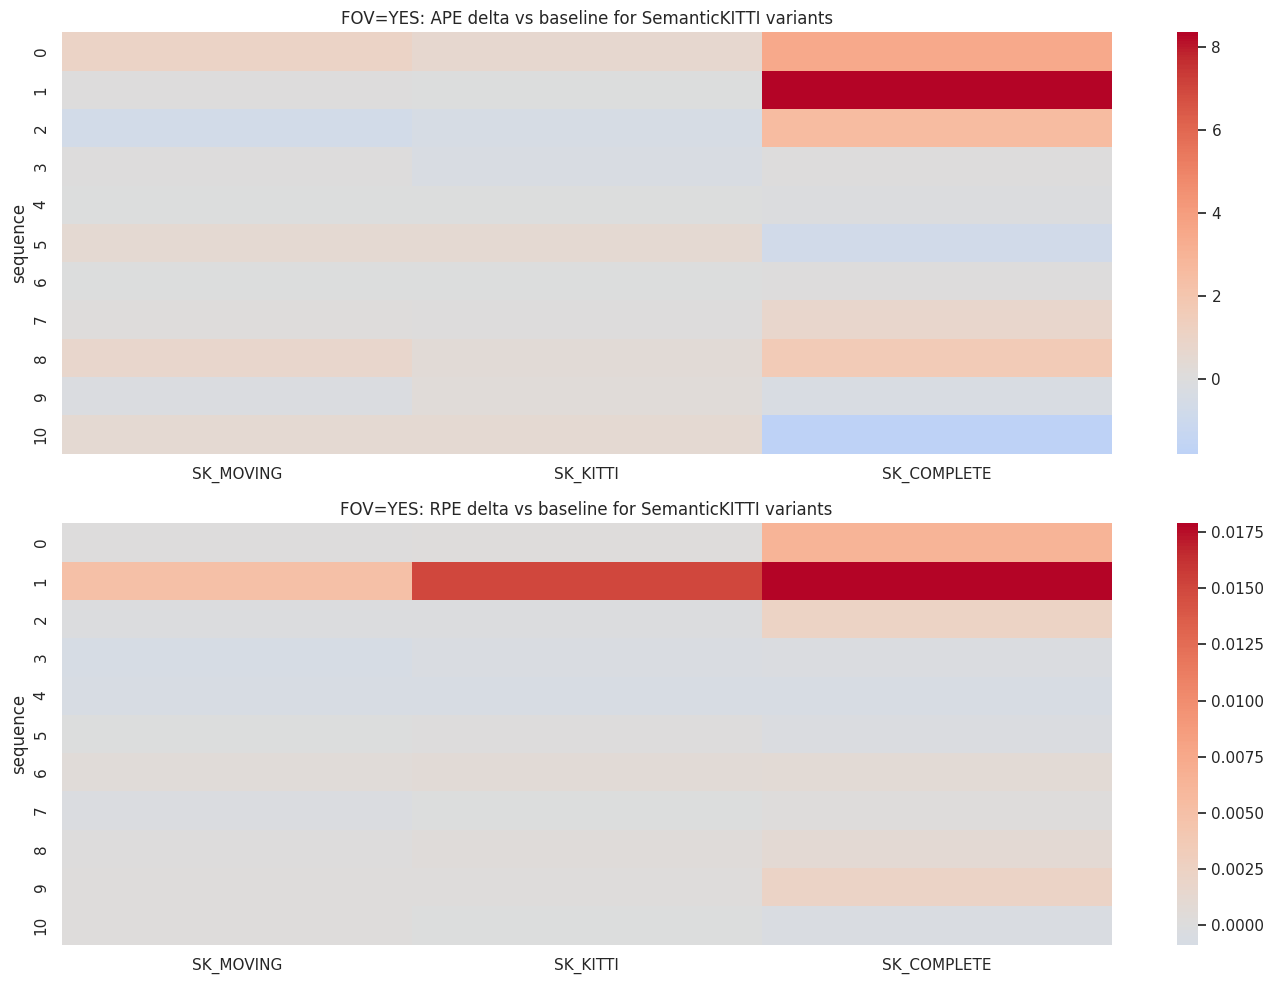

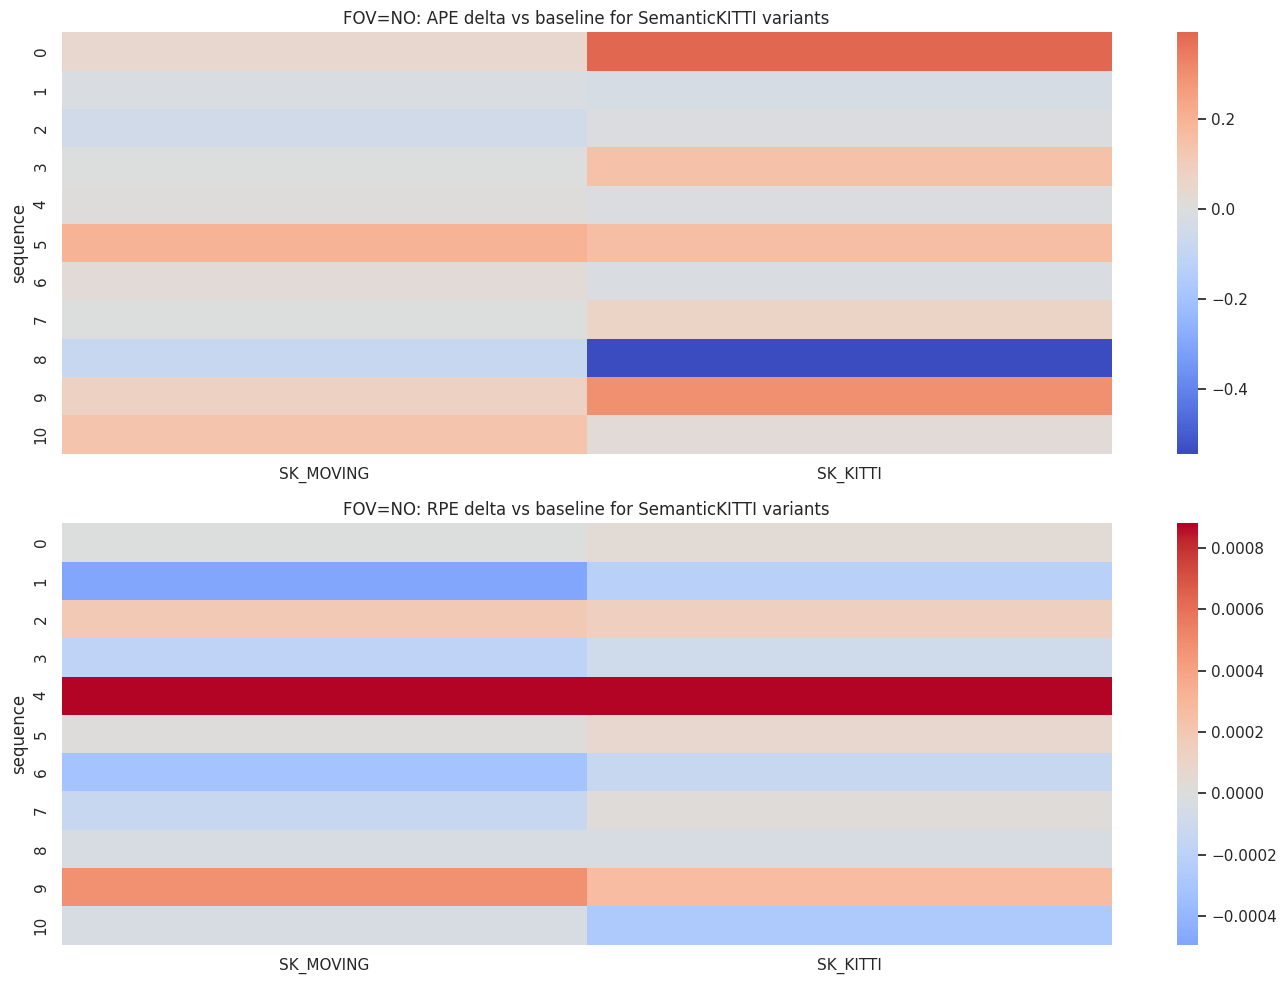

In [60]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
sns.heatmap(sem_yes_ape_delta, cmap='coolwarm', center=0, ax=axes[0])
axes[0].set_title('FOV=YES: APE delta vs baseline for SemanticKITTI variants')
sns.heatmap(sem_yes_rpe_delta, cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('FOV=YES: RPE delta vs baseline for SemanticKITTI variants')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
sns.heatmap(sem_no_ape_delta, cmap='coolwarm', center=0, ax=axes[0])
axes[0].set_title('FOV=NO: APE delta vs baseline for SemanticKITTI variants')
sns.heatmap(sem_no_rpe_delta, cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('FOV=NO: RPE delta vs baseline for SemanticKITTI variants')
plt.tight_layout()
plt.show()

## 5) Sequence-Level Effects

We inspect per-sequence deltas against baseline (`FOV=YES`, `Detector=NO`, `classes=NO`) to find where filtering helps or hurts most.

In [61]:
yes = df[df['FOV'] == 'YES'].copy()
ape_seq = yes.pivot_table(index='sequence', columns=['Detector', 'classes'], values='ape_t_mean', aggfunc='mean')
rpe_seq = yes.pivot_table(index='sequence', columns=['Detector', 'classes'], values='rpe_t_mean', aggfunc='mean')
baseline_col = ('NO', 'NO')
ape_seq_delta = ape_seq.subtract(ape_seq[baseline_col], axis=0)
rpe_seq_delta = rpe_seq.subtract(rpe_seq[baseline_col], axis=0)
display(ape_seq_delta)
display(rpe_seq_delta)

Detector   3D-MOOD                 NO   PV-RCNN   SEM KITTI                    
classes      KITTI MOOD_COMPLETE   NO     KITTI SK_COMPLETE  SK_KITTI SK_MOVING
sequence                                                                       
0         0.065548      0.125614  0.0  0.624929    3.496939  0.657781  1.012073
1         0.475859     -0.229325  0.0  0.054159    8.348011 -0.041844  0.038540
2        -0.423167     -1.105085  0.0 -1.458285    2.603327 -0.408135 -0.661288
3        -0.281037     -0.226118  0.0 -0.155179    0.061518 -0.302213  0.026266
4        -0.018079     -0.034472  0.0 -0.029725   -0.061916 -0.020556 -0.028643
5         0.368939      0.153158  0.0  0.539606   -0.741806  0.472387  0.515016
6         0.062194      0.006817  0.0 -0.071066    0.034252 -0.022868 -0.026807
7         0.317429      0.573677  0.0  0.546572    0.735965  0.001139  0.135817
8        -0.172681      0.411871  0.0  0.335134    1.626838  0.275453  0.733901
9         0.022218      0.411227  0.0 -0.264613   -0.276476  0.223999 -0.185252
10        0.379033      0.018467  0.0  0.717335   -1.784903  0.535658  0.486610

Detector       3D-MOOD                 NO   PV-RCNN   SEM KITTI                    
classes          KITTI MOOD_COMPLETE   NO     KITTI SK_COMPLETE  SK_KITTI SK_MOVING
sequence                                                                           
0         7.776250e-05      0.000169  0.0  0.000114    0.006417  0.000244  0.000017
1         3.341595e-04     -0.001021  0.0  0.000528    0.017898  0.015098  0.004934
2        -7.551800e-05     -0.000051  0.0 -0.000005    0.002350 -0.000083 -0.000209
3        -6.687555e-04     -0.000523  0.0 -0.000608   -0.000283 -0.000393 -0.000879
4        -6.847285e-04     -0.001248  0.0 -0.000113   -0.000792 -0.000730 -0.000676
5         8.775100e-05      0.000200  0.0  0.000214   -0.000348  0.000107 -0.000004
6         5.271055e-04      0.000735  0.0  0.000555    0.000868  0.000720  0.000474
7         2.612155e-04      0.000316  0.0  0.000119    0.000168 -0.000021 -0.000301
8         2.105820e-04      0.000362  0.0  0.000368    0.000931  0.000386  0.000131
9         2.154665e-04      0.000355  0.0  0.000329    0.002231  0.000258  0.000158
10       -5.120000e-07      0.000323  0.0  0.000218   -0.000501 -0.000064  0.000179

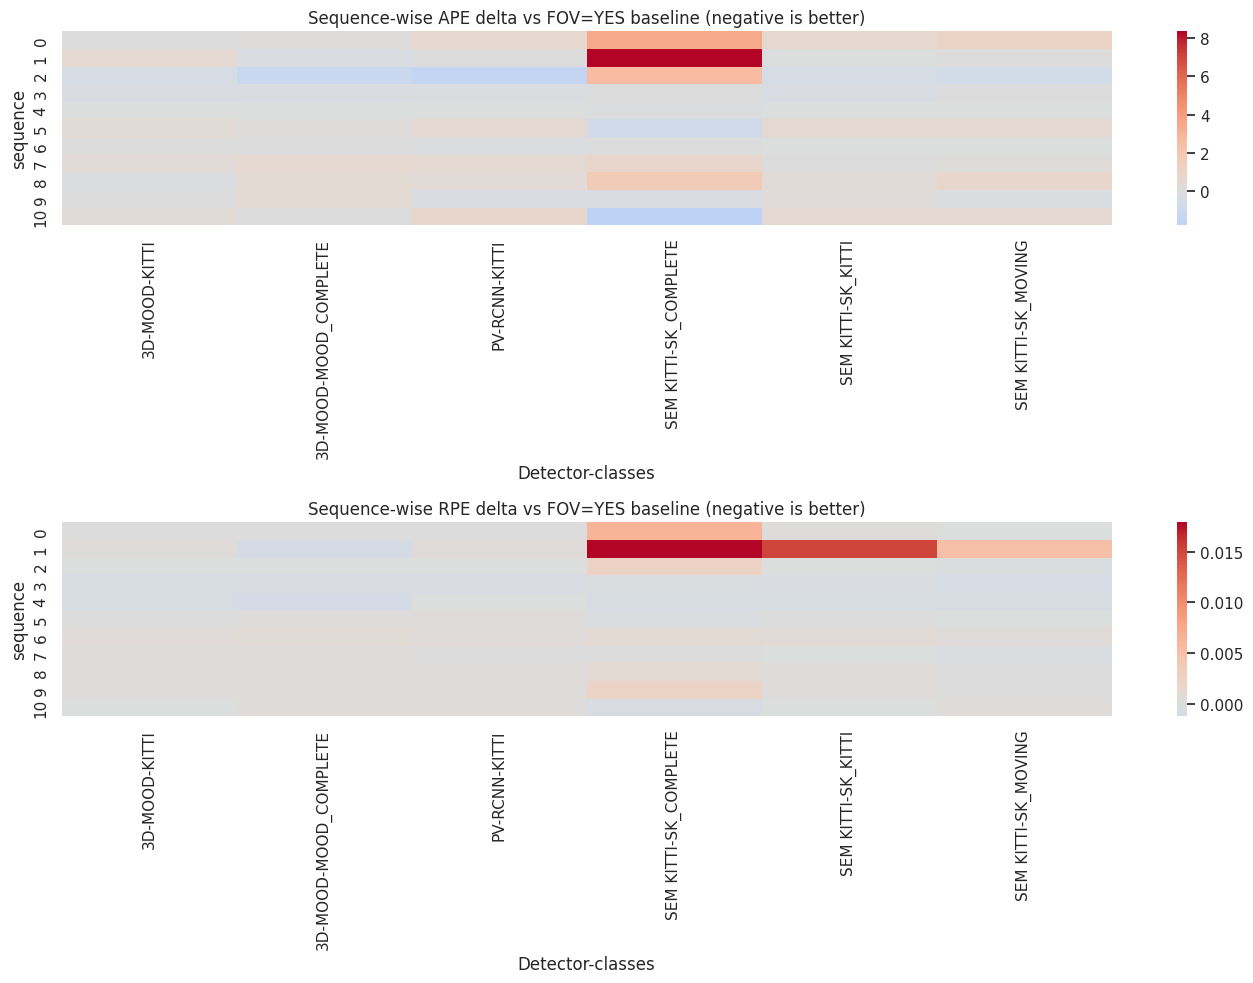

In [62]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
sns.heatmap(ape_seq_delta.drop(columns=[baseline_col], errors='ignore'), cmap='coolwarm', center=0, ax=axes[0])
axes[0].set_title('Sequence-wise APE delta vs FOV=YES baseline (negative is better)')
sns.heatmap(rpe_seq_delta.drop(columns=[baseline_col], errors='ignore'), cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Sequence-wise RPE delta vs FOV=YES baseline (negative is better)')
plt.tight_layout()
plt.show()

## 6) Compact Conclusions Table

This cell creates quick rankings and simple takeaways directly from the data.

In [63]:
rank_ape = summary.sort_values('ape_t_mean').reset_index(drop=True)
rank_rpe = summary.sort_values('rpe_t_mean').reset_index(drop=True)
display(rank_ape[['FOV', 'Detector', 'classes', 'ape_t_mean', 'rpe_t_mean']].head(5))
display(rank_rpe[['FOV', 'Detector', 'classes', 'rpe_t_mean', 'ape_t_mean']].head(5))
print('Best APE config:')
print(rank_ape.iloc[0][['FOV', 'Detector', 'classes', 'ape_t_mean']])
print('Best RPE config:')
print(rank_rpe.iloc[0][['FOV', 'Detector', 'classes', 'rpe_t_mean']])
print('SK_MOVING is now directly comparable under FOV=YES and can be checked against both the baseline and the more aggressive SemanticKITTI filters.')

,FOV,Detector,classes,ape_t_mean,rpe_t_mean
0,YES,NO,NO,11.008873,0.026737
1,YES,3D-MOOD,MOOD_COMPLETE,11.018494,0.026702
2,YES,3D-MOOD,KITTI,11.081260,0.026763
3,YES,PV-RCNN,KITTI,11.085133,0.026893
4,YES,SEM KITTI,SK_KITTI,11.133491,0.028148


,FOV,Detector,classes,rpe_t_mean,ape_t_mean
0,NO,NO,NO,0.024804,17.852906
1,NO,SEM KITTI,SK_MOVING,0.024835,17.882594
2,NO,SEM KITTI,SK_KITTI,0.024866,17.895535
3,NO,PV-RCNN,KITTI,0.024871,17.877090
4,YES,3D-MOOD,MOOD_COMPLETE,0.026702,11.018494


Best APE config:
FOV                 YES
Detector             NO
classes              NO
ape_t_mean    11.008873
Name: 0, dtype: object
Best RPE config:
FOV                 NO
Detector            NO
classes             NO
rpe_t_mean    0.024804
Name: 0, dtype: object
SK_MOVING is now directly comparable under FOV=YES and can be checked against both the baseline and the more aggressive SemanticKITTI filters.
